In [36]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import missingno as msno


In [37]:
HERE = os.path.abspath('')      
DATA_DIR = os.path.join(HERE, "data")
PATH = os.path.join(DATA_DIR, "ai_productivity_dataset_final.csv")

In [38]:
df_productivity = pd.read_csv(PATH)
df_productivity.head()

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2


In [39]:
df_productivity.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


In [40]:
df_productivity.shape

(3248, 34)

In [41]:
df_productivity.info()

<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sla_breach     

In [42]:
df_productivity.columns

Index(['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type',
       'seniority', 'task_complexity_score', 'brief_quality_score',
       'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at',
       'delivered_at', 'sla_days', 'sla_breach', 'hours_spent',
       'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors',
       'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit',
       'created_by', 'updated_at', 'task_status', 'workflow_stage',
       'jira_ticket', 'legacy_ai_flag', 'content_version'],
      dtype='str')

In [43]:
df_productivity.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


## Dataset Overview and Descriptive Statistics

The dataset contains 3,248 observations, each representing a single task performed within a business workflow. The unit of analysis is therefore at the task level, enabling a granular assessment of operational performance.

The dataset includes variables related to:
- operational efficiency (e.g., hours_spent, billable_hours),
- AI adoption (e.g., ai_usage_pct),
- quality and process performance (e.g., revisions, errors, rework_hours),
- economic outcomes (e.g., revenue, cost, profit).

---

## Descriptive Statistics

The summary statistics provide initial insights into the distribution and variability of the key variables.

### Profit

The average profit is approximately 349, while the median is lower (around 255), indicating a right-skewed distribution. The presence of strongly negative values (minimum ≈ -8510) suggests that some tasks generate substantial losses. In addition, the high standard deviation (≈ 888) reflects significant variability in profitability across tasks.

This indicates that profit is not uniformly distributed and motivates further investigation into the drivers of both high and low performance.

---

### AI Usage

The average AI usage is approximately 36%, with values ranging from 0% to 93%. This indicates that AI is not uniformly adopted across tasks but varies significantly.

This variability is particularly important, as it enables the analysis of non-linear relationships and the identification of potential threshold effects.

---

### Time and Efficiency

The average time spent per task is approximately 13 hours, with a median of about 11 hours. The presence of extreme values (maximum ≈ 263 hours) suggests the existence of outliers or highly complex tasks.

This implies that efficiency gains from AI may not be homogeneous across different types of tasks.

---

### Rework and Quality

The average rework time is approximately 2.4 hours, with a highly skewed distribution and a maximum value exceeding 57 hours. This suggests that a small number of tasks may generate disproportionately high levels of rework.

This observation is consistent with the hypothesis that quality instability may play a significant role in affecting overall performance.

---

### Data Quality Considerations

Some variables, including ai_usage_pct, rework_hours, and billable_hours, contain missing values. Rather than being treated solely as technical issues, these missing values may reflect real-world data collection limitations or process inefficiencies.

---

## Implications for Further Analysis

The descriptive analysis highlights three key aspects:

1. Profitability is highly variable, suggesting heterogeneous effects across tasks.
2. AI usage is continuous rather than binary, allowing for the exploration of non-linear relationships.
3. Rework appears to be concentrated in a subset of tasks, indicating potential sources of inefficiency.

These observations motivate a deeper investigation into the relationship between AI usage, efficiency, quality, and profitability.

## MISSING VALUES

In [44]:
missing = df_productivity.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

jira_ticket            339
ai_usage_pct           144
outcome_score          133
billable_hours          82
rework_hours            72
brief_quality_score     69
delivered_at            38
sla_days                36
dtype: int64

In [45]:

missing_pct = (df_productivity.isnull().sum() / len(df_productivity)) * 100
missing_pct.sort_values(ascending=False)

jira_ticket              10.437192
ai_usage_pct              4.433498
outcome_score             4.094828
billable_hours            2.524631
rework_hours              2.216749
brief_quality_score       2.124384
delivered_at              1.169951
sla_days                  1.108374
workflow_stage            0.000000
task_status               0.000000
updated_at                0.000000
created_by                0.000000
ai_assisted               0.000000
cost                      0.000000
revenue                   0.000000
legacy_ai_flag            0.000000
errors                    0.000000
revisions                 0.000000
profit                    0.000000
task_id                   0.000000
client                    0.000000
hours_spent               0.000000
sla_breach                0.000000
created_at                0.000000
pricing_model             0.000000
scope_change_flag         0.000000
deadline_pressure         0.000000
task_complexity_score     0.000000
seniority           

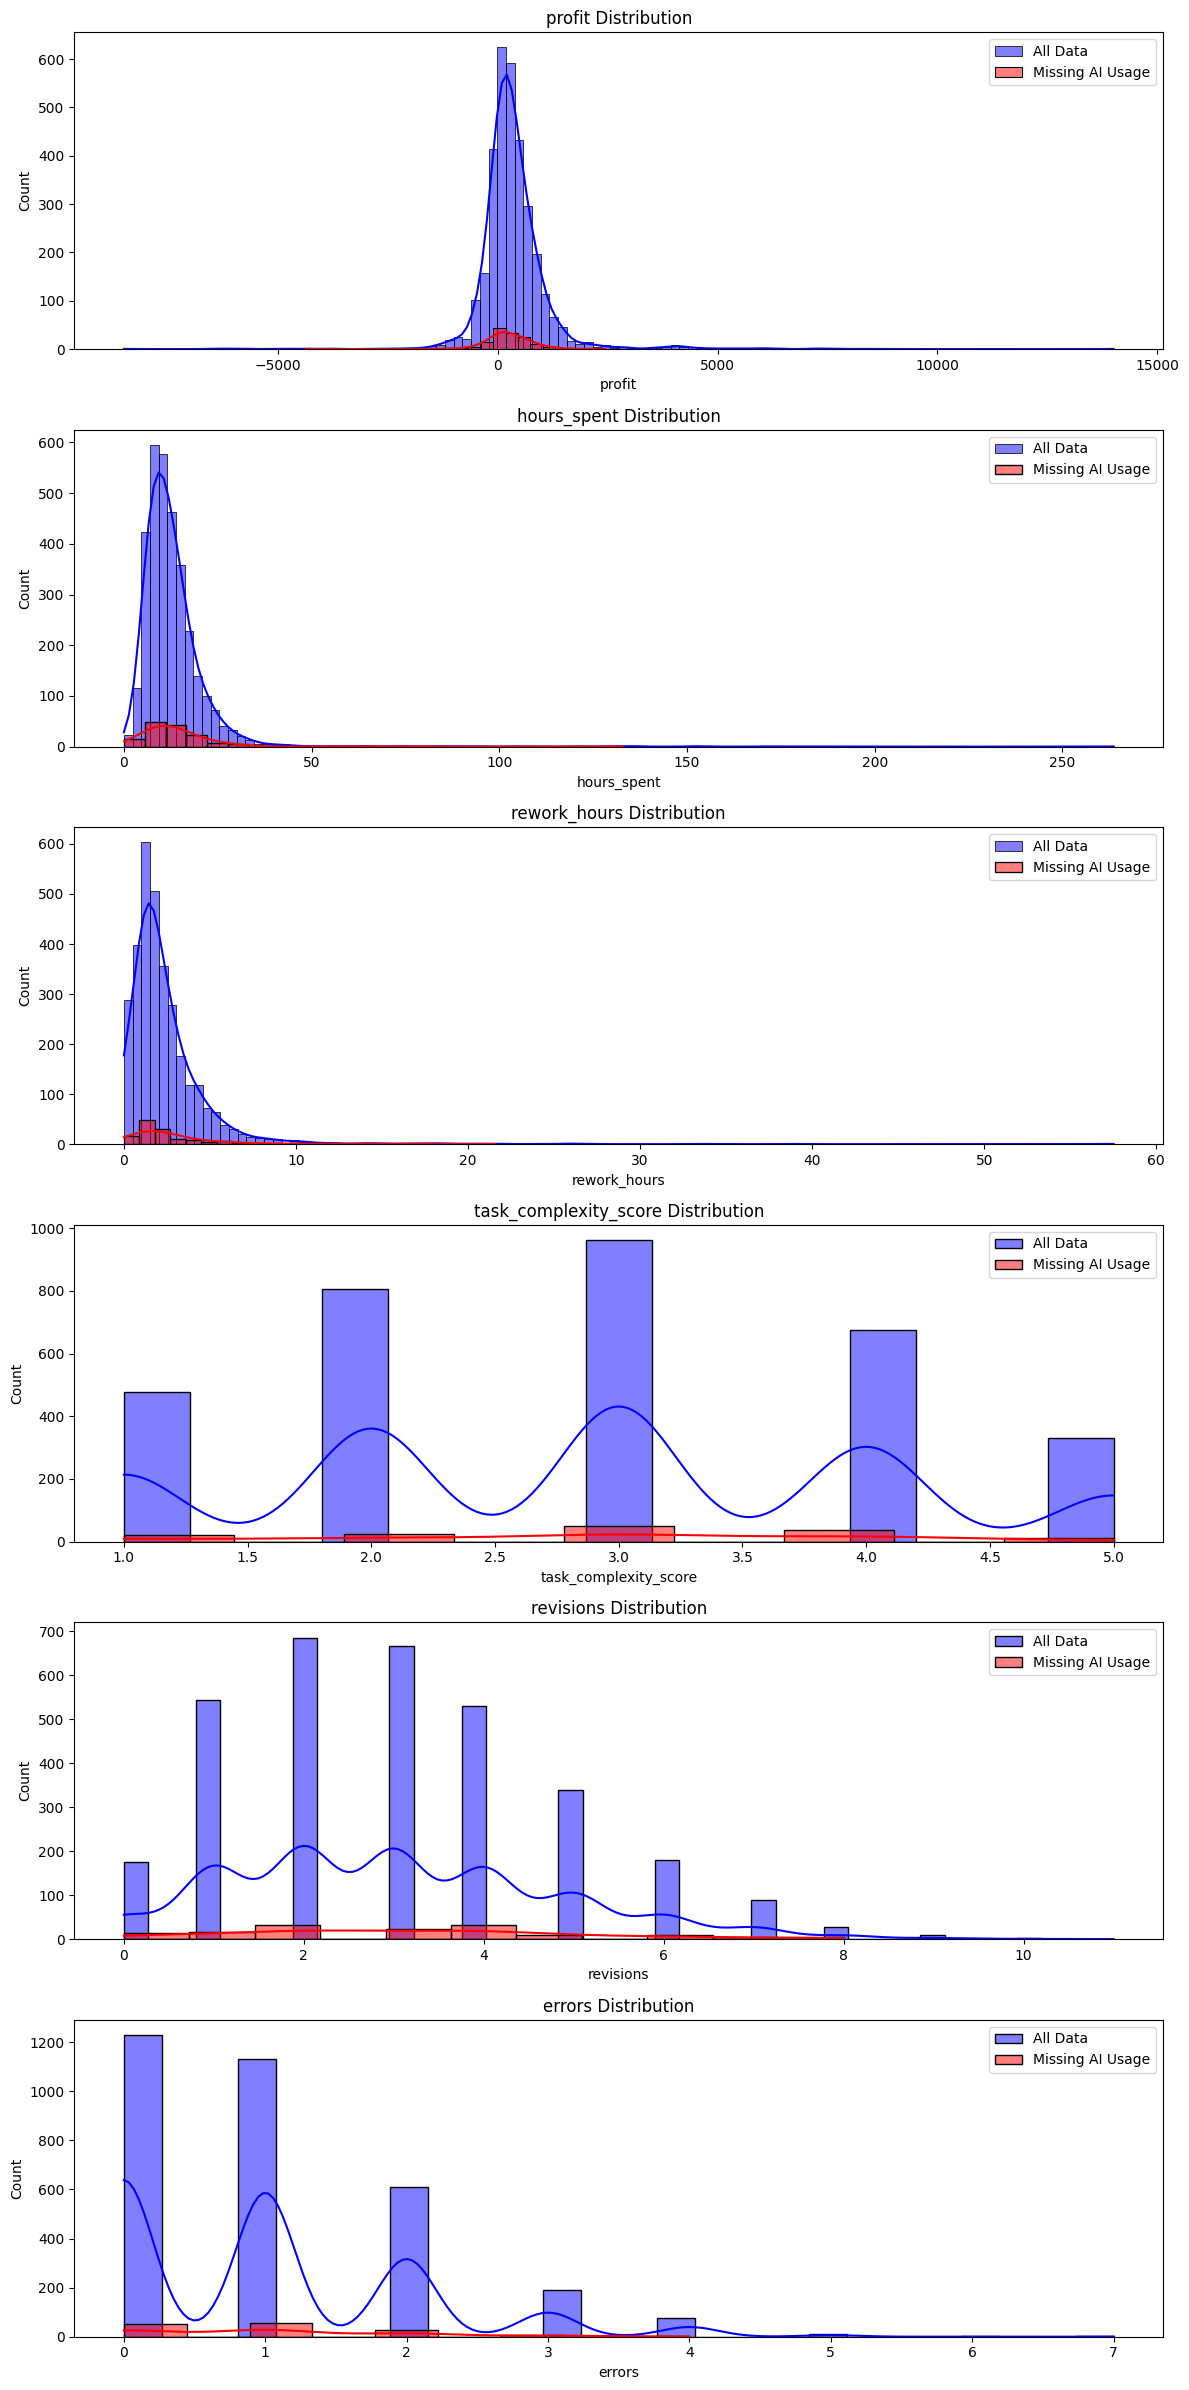

In [57]:
# Filter rows where ai_usage_pct is null
missing_ai_rows = df_productivity[df_productivity['ai_usage_pct'].isnull()]

# Columns to analyze (scelte intelligenti per il progetto)
columns = [
    'profit',
    'hours_spent',
    'rework_hours',
    'task_complexity_score',
    'revisions',
    'errors'
]

# Create subplots
fig, axes = plt.subplots(len(columns), 1, figsize=(12, 4 * len(columns)))

# Loop through columns
for i, column in enumerate(columns):
    
    if column in df_productivity.select_dtypes(include=['int64', 'float64']).columns:
        sns.histplot(df_productivity[column], ax=axes[i], kde=True, color='blue', label='All Data')
        sns.histplot(missing_ai_rows[column], ax=axes[i], kde=True, color='red', label='Missing AI Usage')
    else:
        sns.countplot(data=df_productivity, x=column, ax=axes[i], color='blue', label='All Data')
        sns.countplot(data=missing_ai_rows, x=column, ax=axes[i], color='red', label='Missing AI Usage')
    
    axes[i].set_title(f'{column} Distribution')
    axes[i].set_xlabel(column)
    axes[i].legend()

# Layout
plt.tight_layout()
plt.show()

<Axes: >

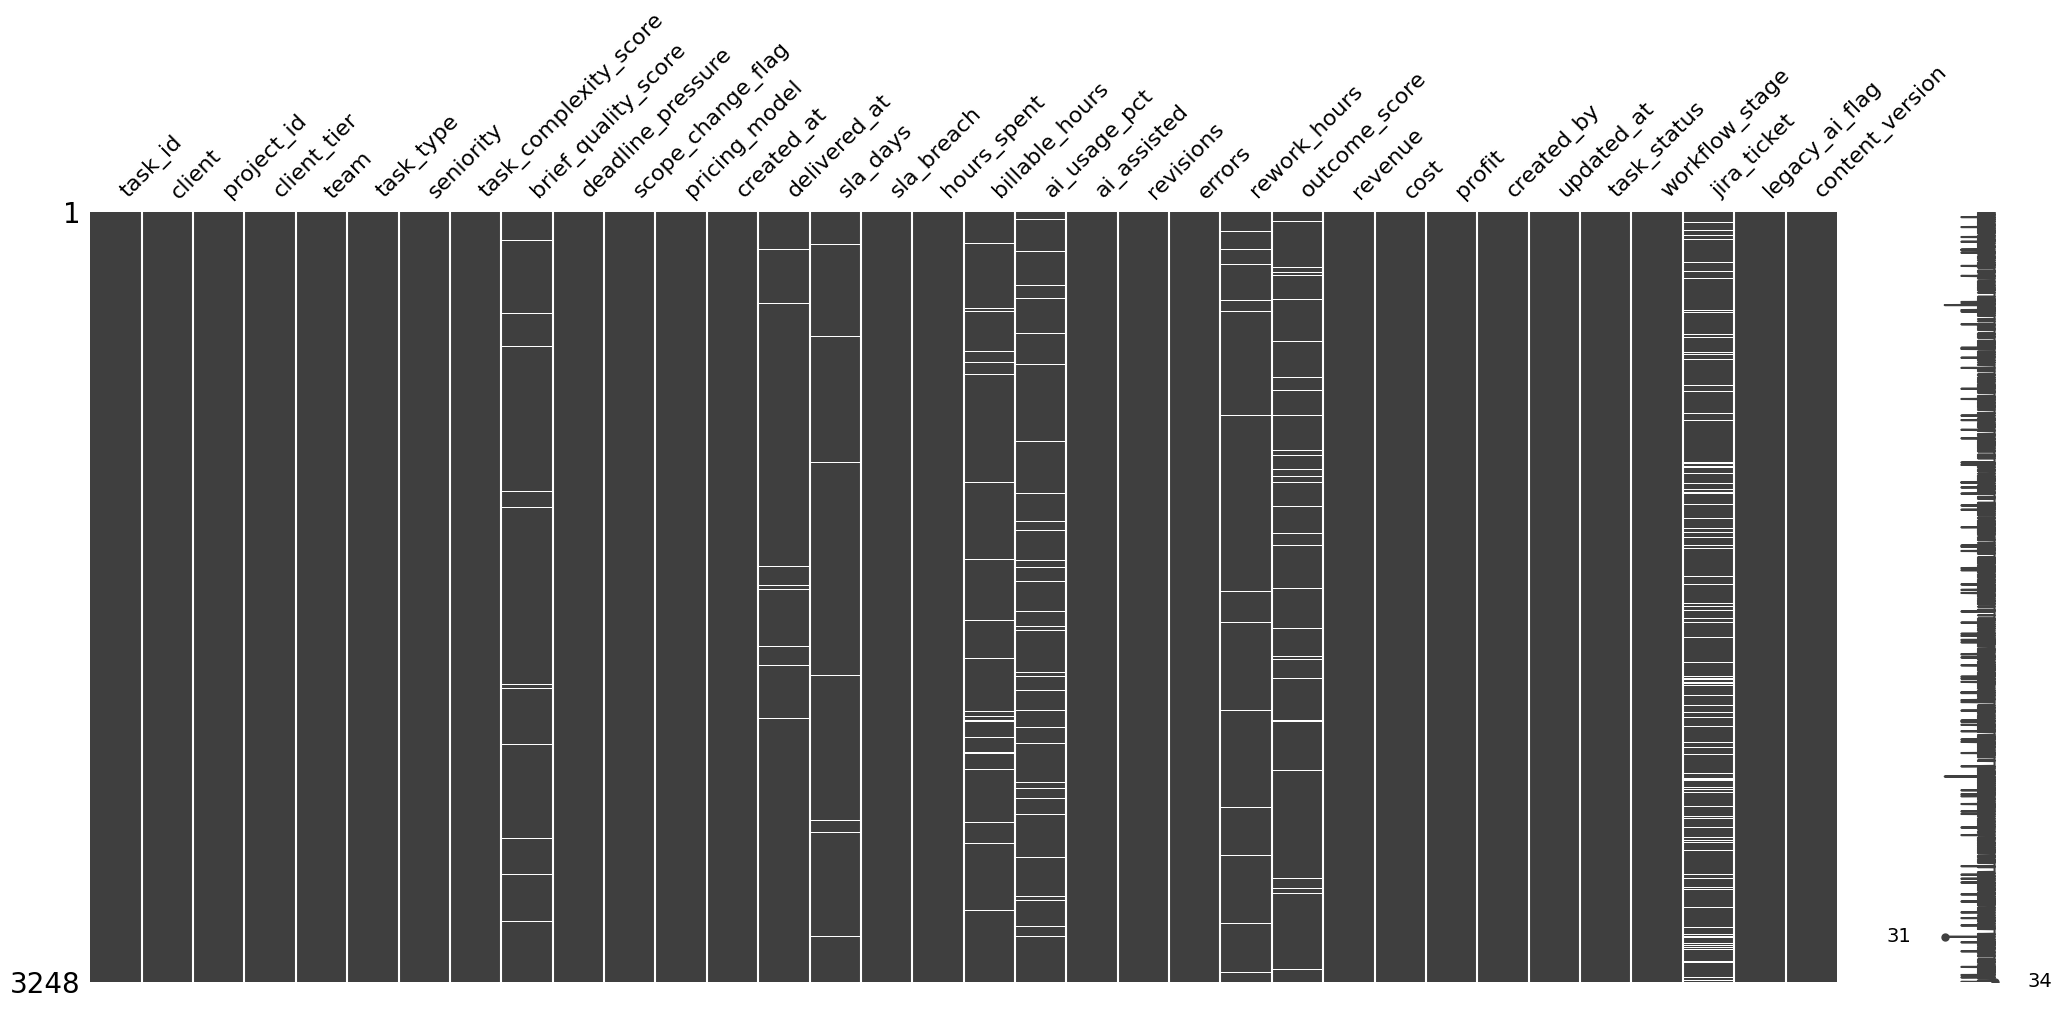

In [46]:
msno.matrix(df_productivity)

## Target Variable : Profit

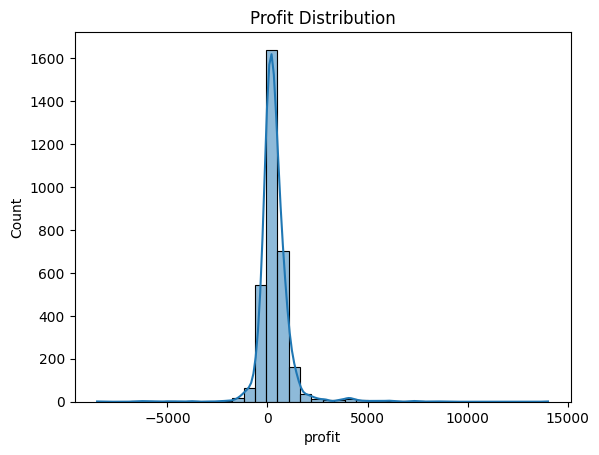

In [47]:
sns.histplot(df_productivity['profit'], bins=40, kde=True)
plt.title("Profit Distribution")
plt.show()

## AI usage 

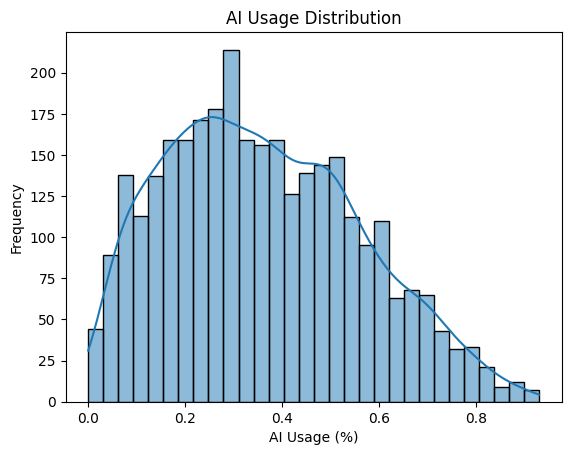

In [48]:
sns.histplot(df_productivity['ai_usage_pct'], bins=30, kde=True)
plt.title("AI Usage Distribution")
plt.xlabel("AI Usage (%)")
plt.ylabel("Frequency")
plt.show()

In [49]:
df_productivity['ai_usage_pct'].describe()

count    3104.000000
mean        0.361717
std         0.199391
min         0.000000
25%         0.200000
50%         0.340000
75%         0.500000
max         0.930000
Name: ai_usage_pct, dtype: float64

## efficiency vs quality

**time**


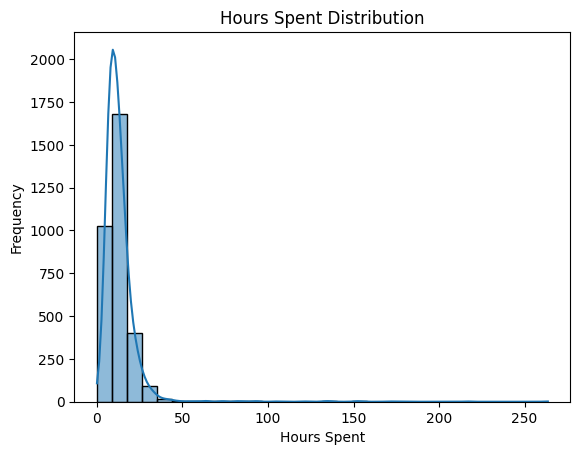

In [50]:
sns.histplot(df_productivity['hours_spent'], bins=30, kde=True)
plt.title("Hours Spent Distribution")
plt.xlabel("Hours Spent")
plt.ylabel("Frequency")
plt.show()

**rework**

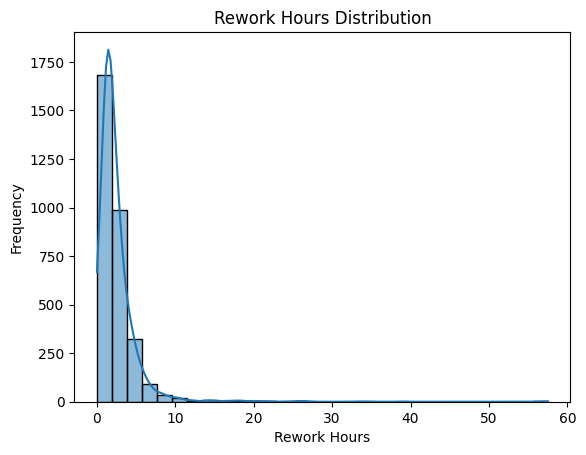

In [51]:
sns.histplot(df_productivity['rework_hours'], bins=30, kde=True)
plt.title("Rework Hours Distribution")
plt.xlabel("Rework Hours")
plt.ylabel("Frequency")
plt.show()

## Correlation

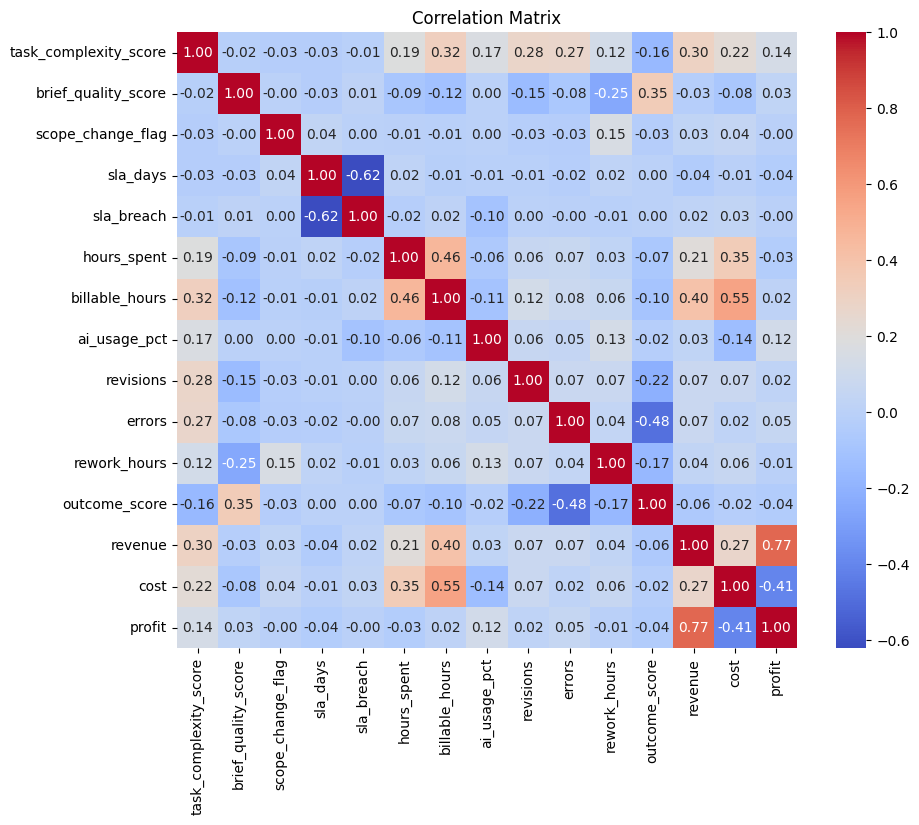

In [54]:
numeric = df_productivity.select_dtypes(include=[np.number])

corr = numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()